Libraries Loaded Successfully

Dataset Path Found:
/kaggle/input/datasets/kavanacv/credit-card/credit_card_frauds.csv

Dataset Loaded Successfully

First 5 Rows:
  trans_date_trans_time                   merchant       category     amt  \
0   2019-01-01 00:00:44  Heller, Gutmann and Zieme    grocery_pos  107.23   
1   2019-01-01 00:00:51             Lind-Buckridge  entertainment  220.11   
2   2019-01-01 00:07:27                  Kiehn Inc    grocery_pos   96.29   
3   2019-01-01 00:09:03                Beier-Hyatt   shopping_pos    7.77   
4   2019-01-01 00:21:32                 Bruen-Yost       misc_pos    6.85   

                       city state      lat      long  city_pop  \
0                    Orient    WA  48.8878 -118.2105       149   
1                Malad City    ID  42.1808 -112.2620      4154   
2                   Grenada    CA  41.6125 -122.5258       589   
3  High Rolls Mountain Park    NM  32.9396 -105.8189       899   
4                   Freedom    WY  43.0172 -1

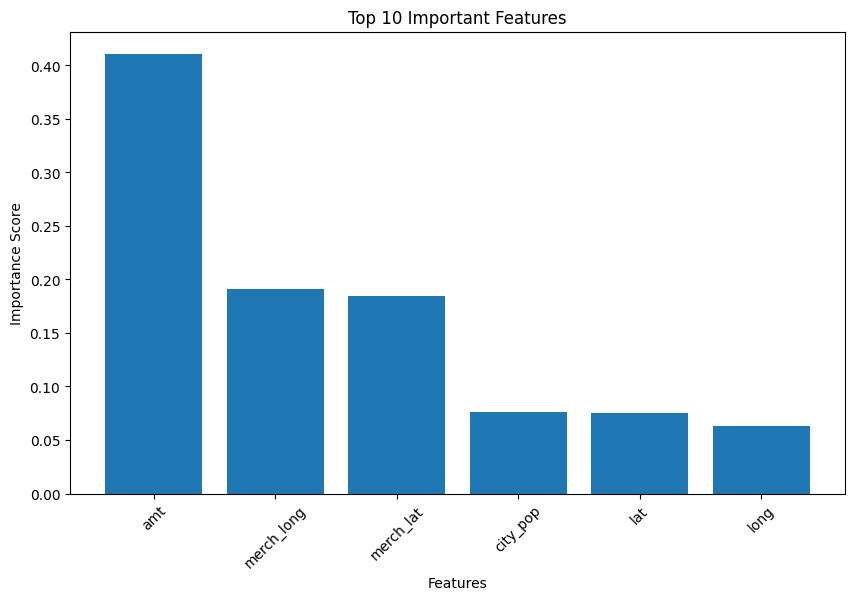


RQ5 Completed Successfully


In [1]:
# =========================================
# RQ5 - Feature Importance Analysis
# =========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Libraries Loaded Successfully")

# =========================================
# FIND DATASET AUTOMATICALLY
# =========================================

csv_path = ""

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_path = os.path.join(dirname, filename)

print("\nDataset Path Found:")
print(csv_path)

# =========================================
# LOAD DATASET
# =========================================

data = pd.read_csv(csv_path)

print("\nDataset Loaded Successfully")

# Display First 5 Rows
print("\nFirst 5 Rows:")
print(data.head())

# =========================================
# PREPROCESSING
# =========================================

# Keep only numeric columns
data_numeric = data.select_dtypes(include=['int64', 'float64'])

# Features and Target
X = data_numeric.drop("is_fraud", axis=1)
y = data_numeric["is_fraud"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nData Split Completed")

# =========================================
# RANDOM FOREST MODEL
# =========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")

# =========================================
# FEATURE IMPORTANCE
# =========================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Save Table
feature_importance.to_csv(
    "RQ5_Feature_Importance.csv",
    index=False
)

# =========================================
# FEATURE IMPORTANCE GRAPH
# =========================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_features['Feature'],
    top_features['Importance']
)

plt.xticks(rotation=45)

plt.title("Top 10 Important Features")

plt.xlabel("Features")
plt.ylabel("Importance Score")

# Save Figure
plt.savefig("RQ5_Feature_Importance.pdf")

plt.show()

print("\nRQ5 Completed Successfully")


# =========================================
# FEATURE IMPORTANCE BAR GRAPH
# =========================================

top_features = feature_importance.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()